In [6]:
import pvlib

from pvlib.modelchain import ModelChain
from pvlib.location import Location
from pvlib.pvsystem import PVSystem
from pvlib.temperature import TEMPERATURE_MODEL_PARAMETERS
import matplotlib.pyplot as plt

import pandas as pd

In [12]:
# -----------------------------
# 1. Location & System Setup
# -----------------------------
location = Location(latitude=28.633, longitude=77.220, tz='Etc/GMT-5', name='Rajiw_Chowk_Delhi', altitude=219)

# Retrieve module & inverter specs from the SAM database
sandia_modules = pvlib.pvsystem.retrieve_sam('SandiaMod')
cec_inverters   = pvlib.pvsystem.retrieve_sam('CECInverter')

module  = sandia_modules['Canadian_Solar_CS5P_220M___2009_']
inverter = cec_inverters['ABB__MICRO_0_25_I_OUTD_US_208__208V_']

tempreature_parameters = TEMPERATURE_MODEL_PARAMETERS['sapm']['open_rack_glass_glass']

system = PVSystem(
    module_parameters=module,
    inverter_parameters=inverter,
    temperature_model_parameters=tempreature_parameters,
    surface_tilt=30,
    surface_azimuth=180,
    module_type=1,
    albedo=0.2,
    modules_per_string=1,
    strings_per_inverter=1,
)

# Create two ModelChain objects: one for measured POA, one for clear‐sky
mc_poa = ModelChain(system, location)
mc_cs  = ModelChain(system, location)

/tmp/ipykernel_84331/178832431.py:29: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  poa_monthly = ac_poa.resample('M').sum()
/tmp/ipykernel_84331/178832431.py:30: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  cs_monthly  = ac_cs.resample('M').sum()


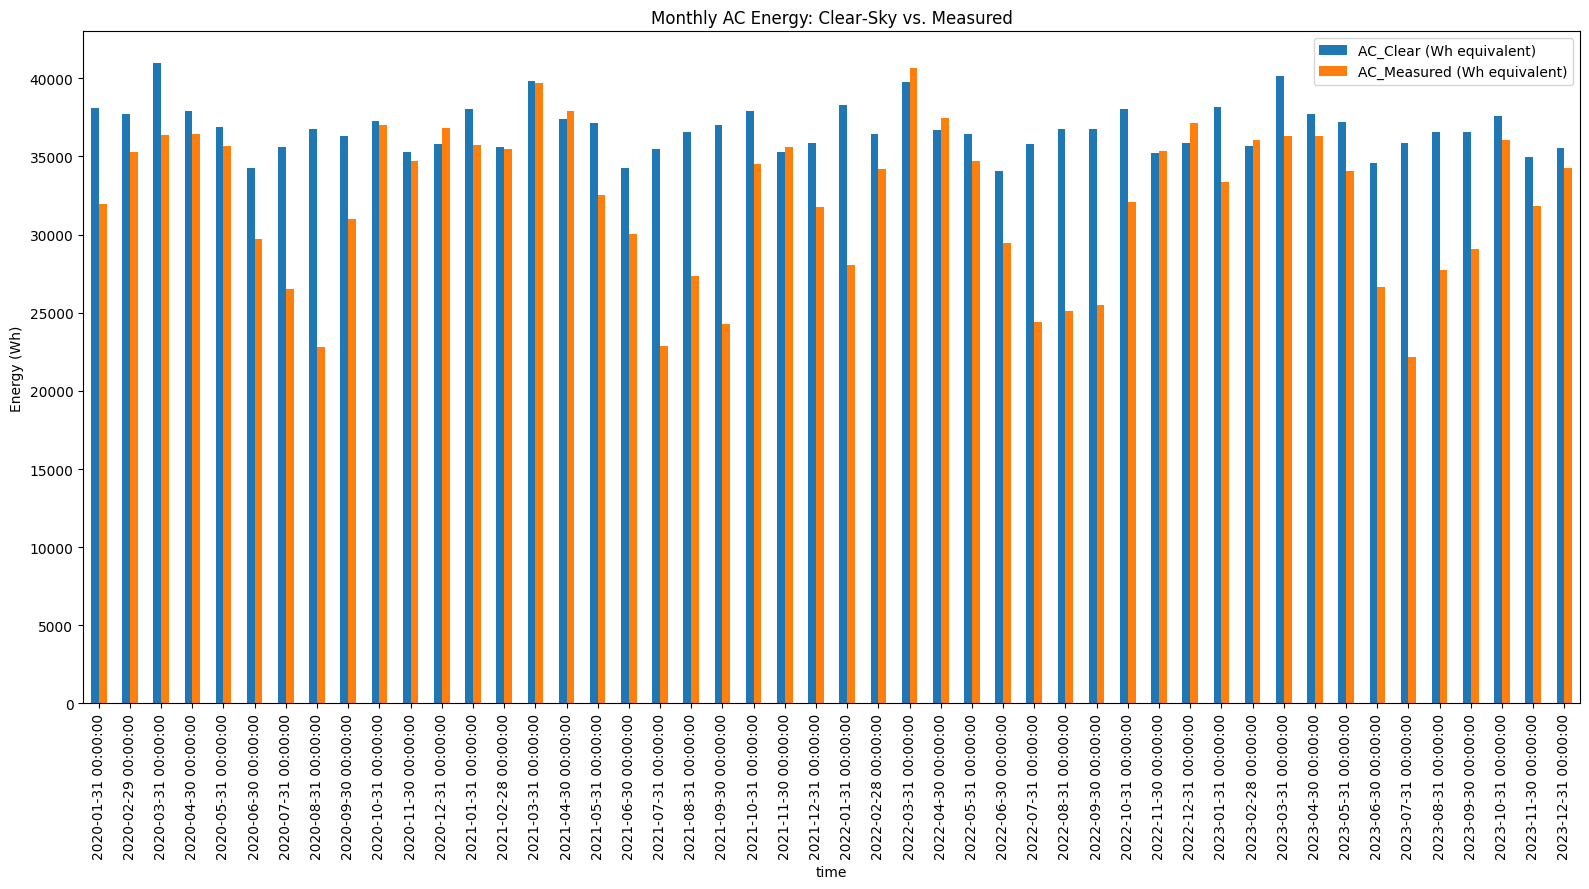

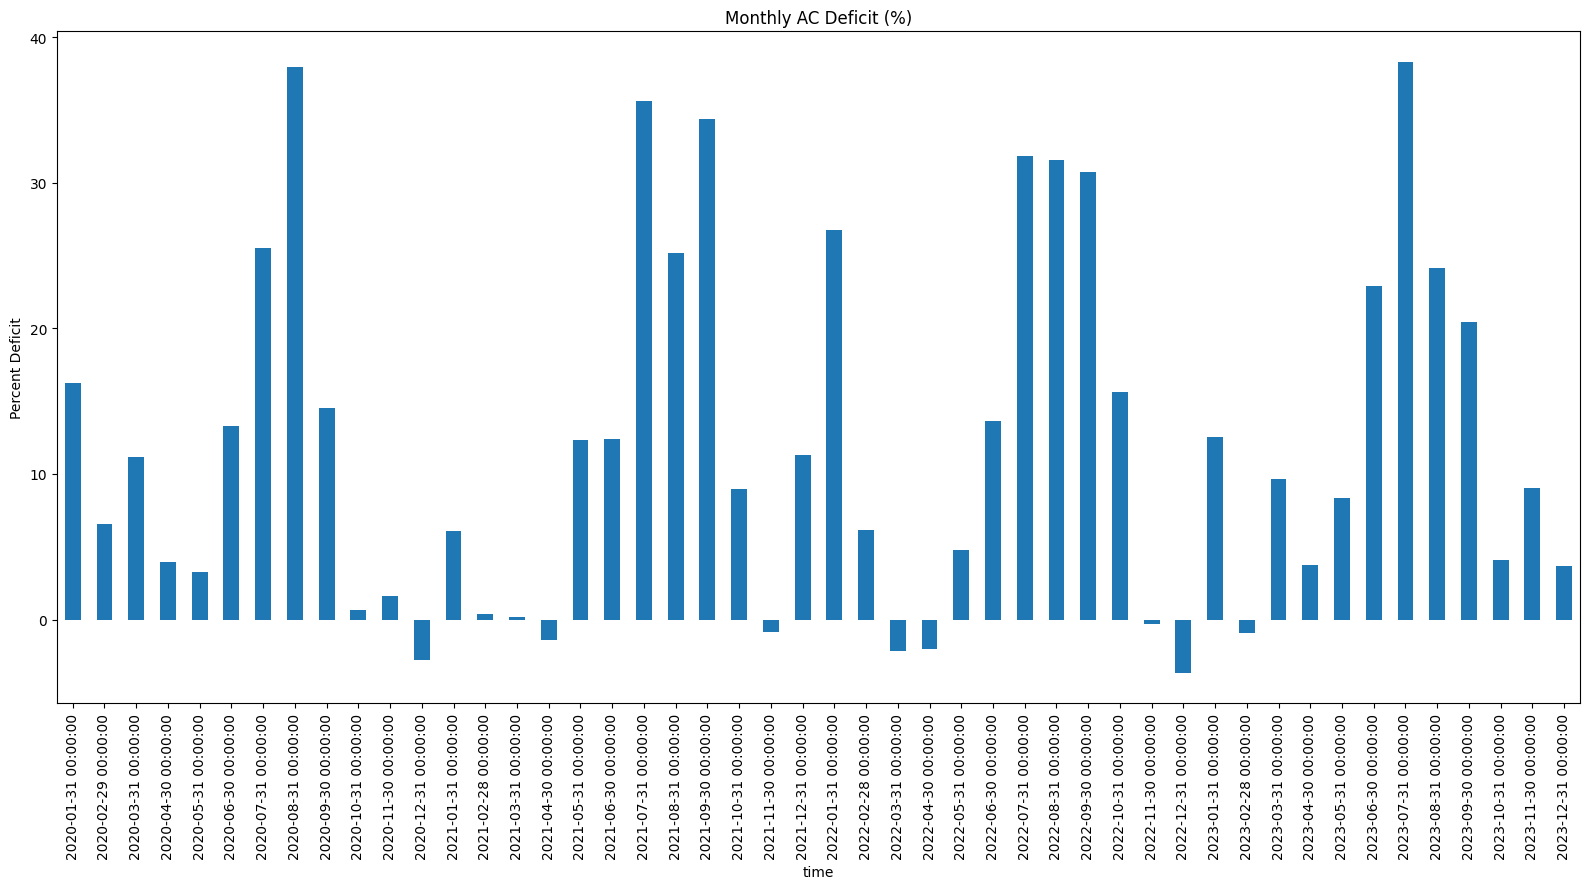

Monthly deficit calculation complete. Results saved to 'monthly_ac_deficit.csv'.


In [13]:

# -----------------------------
# 2. Load Measured POA Data
# -----------------------------
poa = pd.read_csv(
    'delhi_poa_20_23.csv',
    index_col=0,
    parse_dates=True
)

# Run the model using your measured POA inputs
mc_poa.run_model_from_poa(poa)
ac_poa = mc_poa.results.ac

# -----------------------------
# 3. Generate Clear‐Sky Inputs
# -----------------------------
# Use the same timestamps, temperature, and wind speed as your POA dataset
clear_sky = location.get_clearsky(poa.index)
clear_sky['temp_air']   = poa['temp_air']
clear_sky['wind_speed'] = poa['wind_speed']

# Run the model on clear‐sky irradiance
mc_cs.run_model(clear_sky)
ac_cs = mc_cs.results.ac

# -----------------------------
# 4. Monthly Aggregation
# -----------------------------
poa_monthly = ac_poa.resample('M').sum()
cs_monthly  = ac_cs.resample('M').sum()

# -----------------------------
# 5. Compute Deficits
# -----------------------------
df_deficit = pd.DataFrame({
    'AC_Clear (Wh equivalent)':         cs_monthly,
    'AC_Measured (Wh equivalent)':     poa_monthly
})
df_deficit['Deficit_Absolute'] = (
    df_deficit['AC_Clear (Wh equivalent)']
  - df_deficit['AC_Measured (Wh equivalent)']
)
df_deficit['Deficit_Percent'] = (
    df_deficit['Deficit_Absolute']
  / df_deficit['AC_Clear (Wh equivalent)']
  * 100.0
)

# -----------------------------
# 6. Plot Results
# -----------------------------
# Clear‐sky vs. Measured Monthly Energy
df_deficit[['AC_Clear (Wh equivalent)', 'AC_Measured (Wh equivalent)']] \
    .plot(kind='bar', figsize=(16, 9),
          title='Monthly AC Energy: Clear‐Sky vs. Measured')
plt.ylabel('Energy (Wh)')
plt.tight_layout()
plt.show()

# Monthly Deficit Percentage
df_deficit['Deficit_Percent'] \
    .plot(kind='bar', figsize=(16, 9),
          title='Monthly AC Deficit (%)')
plt.ylabel('Percent Deficit')
plt.tight_layout()
plt.show()

# -----------------------------
# 7. Save to CSV
# -----------------------------
df_deficit.to_csv('monthly_ac_deficit.csv')
print("Monthly deficit calculation complete. Results saved to 'monthly_ac_deficit.csv'.")


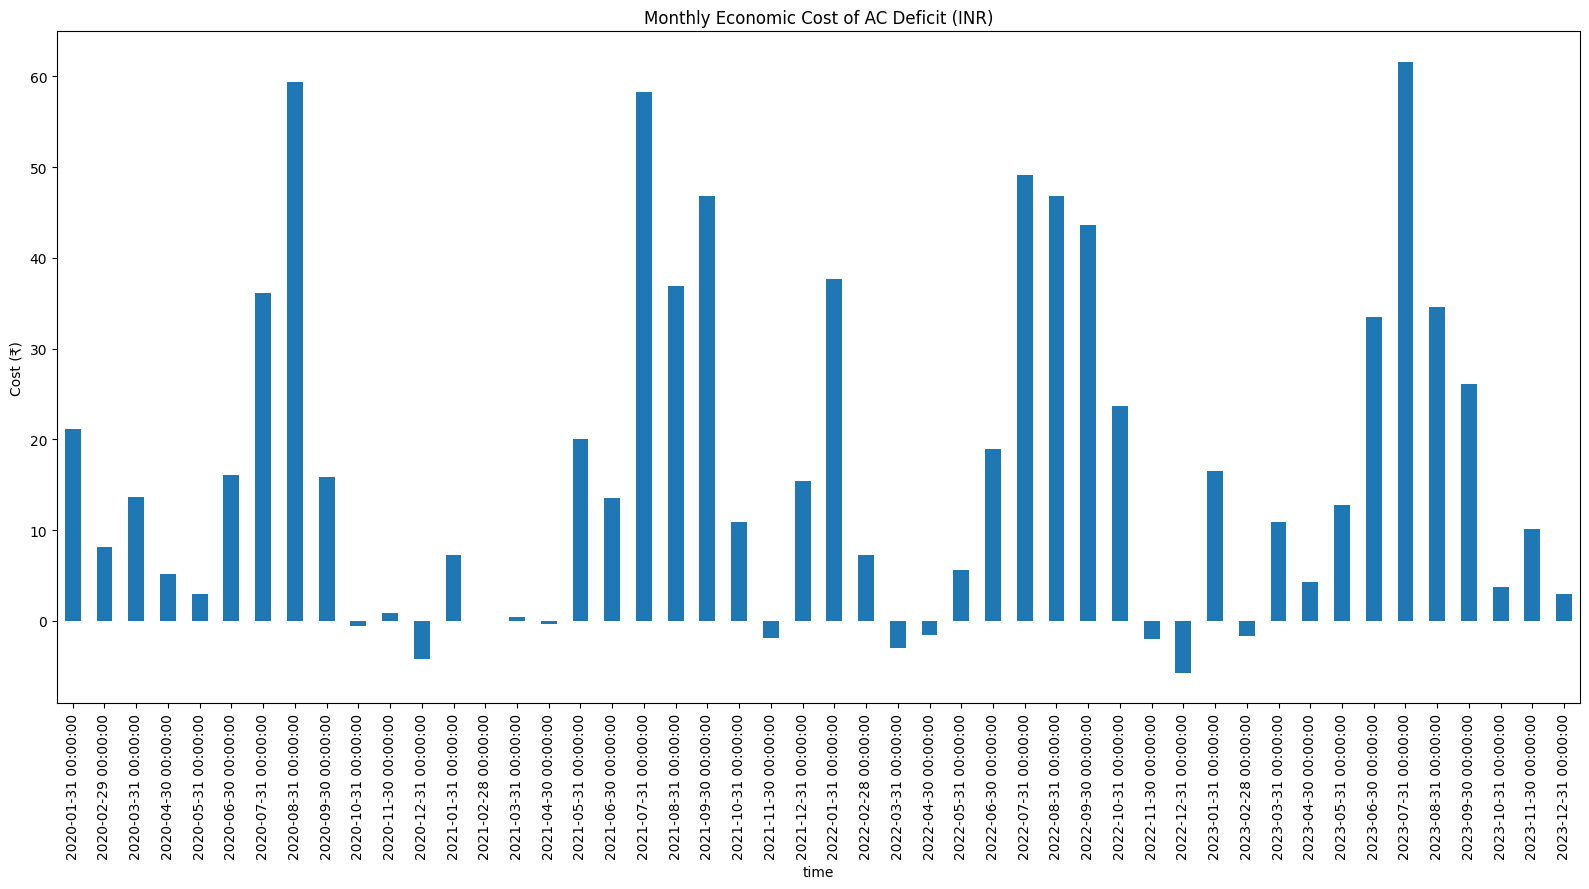

Saved updated deficit + cost to 'monthly_ac_deficit_with_cost.csv'


In [9]:
# ---- 8. Economic Cost of Deficit ----

# First convert Wh deficit → kWh
df_deficit['Deficit_kWh'] = df_deficit['Deficit_Absolute'] / 1000.0

# Define Delhi slab tariff (INR per kWh)
def compute_cost(kwh):
    cost = 0.0
    remaining = kwh
    # slabs: (size in kWh, rate INR/kWh)
    slabs = [
        (200,   3.00),
        (200,   4.50),
        (400,   6.50),
        (400,   7.00),  # this covers up to 1200 kWh
    ]
    for size, rate in slabs:
        take = min(remaining, size)
        cost += take * rate
        remaining -= take
        if remaining <= 0:
            return cost
    # any above 1200 kWh at ₹ 8.00/kWh
    cost += remaining * 8.00
    return cost

# Apply the cost function to each month
df_deficit['Cost_INR'] = df_deficit['Deficit_kWh'].apply(compute_cost)

# Plot the monthly economic cost
df_deficit['Cost_INR'] \
    .plot(kind='bar',
          figsize=(16, 9),
          title='Monthly Economic Cost of AC Deficit (INR)')  
plt.ylabel('Cost (₹)')  
plt.tight_layout()  
plt.show()

# (Optional) save with costs
df_deficit.to_csv('monthly_ac_deficit_with_cost.csv')
print("Saved updated deficit + cost to 'monthly_ac_deficit_with_cost.csv'")
